In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parents[0]))

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from config import PROCESSED_DATA_DIR

In [2]:
reviews_df = pd.read_parquet(PROCESSED_DATA_DIR / "amazon_reviews_clean.parquet")

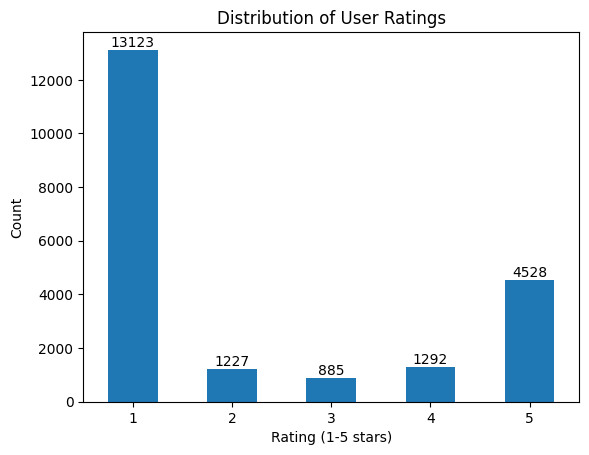

In [3]:
ax = reviews_df["rating"].value_counts().sort_index().plot(kind="bar")

for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.title("Distribution of User Ratings")
plt.xlabel("Rating (1-5 stars)")
plt.xticks(rotation=0)
plt.ylabel("Count")
plt.show()

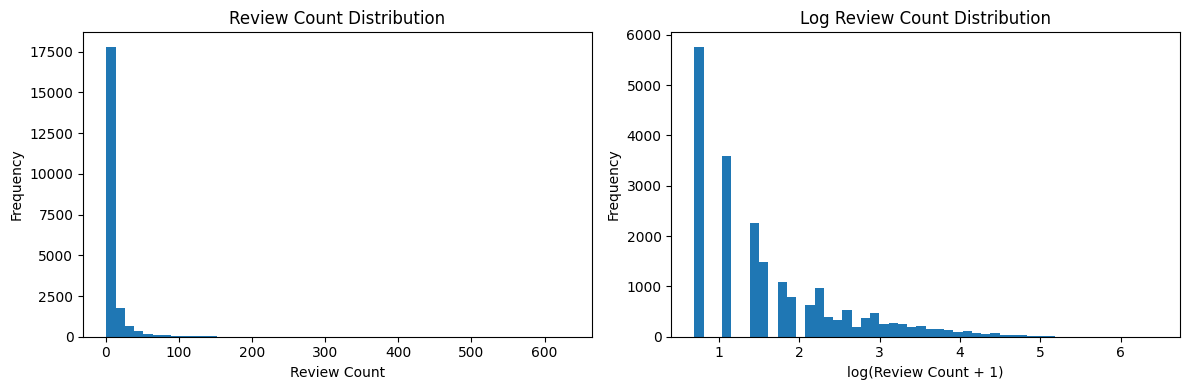

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: raw review count
axes[0].hist(reviews_df["review_count"], bins=50)
axes[0].set_title("Review Count Distribution")
axes[0].set_xlabel("Review Count")
axes[0].set_ylabel("Frequency")

# Right: log-transformed
axes[1].hist(np.log1p(reviews_df["review_count"]), bins=50)
axes[1].set_title("Log Review Count Distribution")
axes[1].set_xlabel("log(Review Count + 1)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

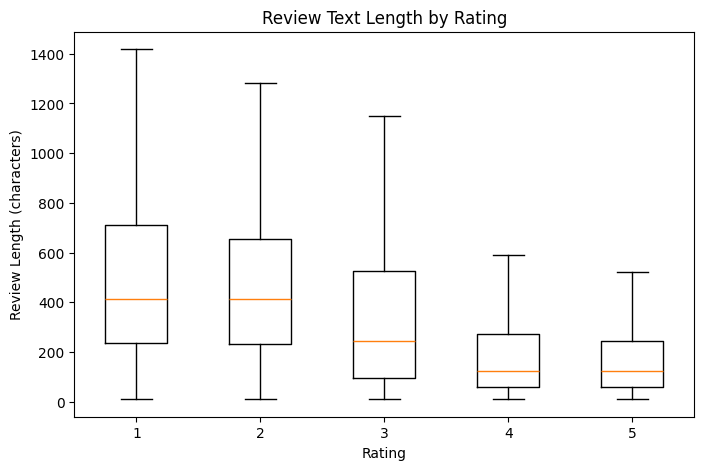

In [5]:
reviews_df["review_length"] = reviews_df["review_text"].str.len()

rating_groups = [
    reviews_df.loc[reviews_df["rating"] == rating, "review_length"]
    for rating in sorted(reviews_df["rating"].unique())
]

plt.figure(figsize=(8, 5))
plt.boxplot(rating_groups, tick_labels=sorted(reviews_df["rating"].unique()), showfliers=False)
plt.title("Review Text Length by Rating")
plt.xlabel("Rating")
plt.ylabel("Review Length (characters)")
plt.show()

In [6]:
reviews_df["review_count"].describe()

count    21055.000000
mean         8.488720
std         18.239247
min          1.000000
25%          1.000000
50%          3.000000
75%          8.000000
max        633.000000
Name: review_count, dtype: float64

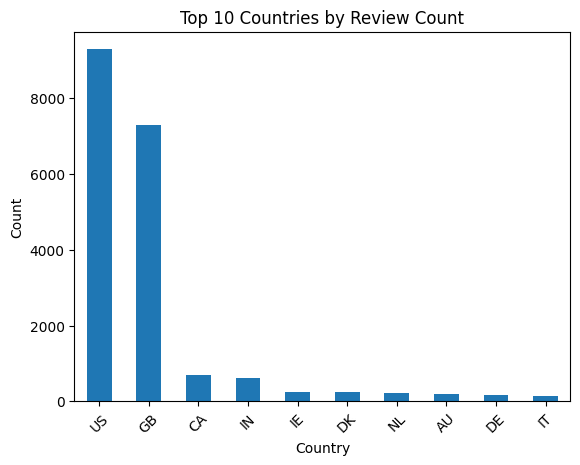

In [7]:
reviews_df["country"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Countries by Review Count")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

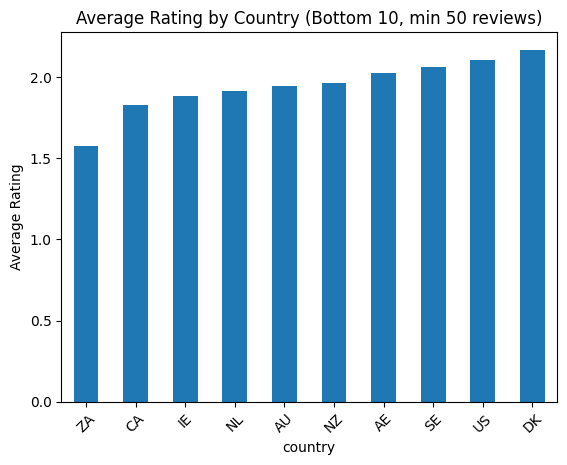

In [8]:
country_stats = reviews_df.groupby("country").agg(
    avg_rating=("rating", "mean"),
    count=("rating", "size")
)

filtered = country_stats[country_stats["count"] >= 50]

filtered["avg_rating"].sort_values().head(10).plot(kind="bar")
plt.title("Average Rating by Country (Bottom 10, min 50 reviews)")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()